Task 1 — Build & Evaluate a Linear Regression Model House Price Predictor | California Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:

# LOAD DATASET 
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print(f"\n Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


 Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252   41.0000    6.9841     1.0238    322.0000    2.5556   37.8800   
1  8.3014   21.0000    6.2381     0.9719   2401.0000    2.1098   37.8600   
2  7.2574   52.0000    8.2881     1.0734    496.0000    2.8023   37.8500   
3  5.6431   52.0000    5.8174     1.0731    558.0000    2.5479   37.8500   
4  3.8462   52.0000    6.2819     1.0811    565.0000    2.1815   37.8500   

   Longitude  MedHouseVal  
0  -122.2300       4.5260  
1  -122.2200       3.5850  
2  -122.2400       3.5210  
3  -122.2500       3.4130  
4  -122.2500       3.4220  



 Statistical Summary:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count 20640.0000 20640.0000 20640.0000 20640.0000  20640.0000 20640.0000   
mean      3.8700    28.6400     5.4300     1.1000   1425.4800     3.0700   
std       1.9000    12.5900     2.4700     0.4700   1132.4600    10.3900   
min       0.5000     1.0000     0.8500     0.3300      3.0000     0.6900   
25%       2.5600    18.0000     4.4400     1.0100    787.0000     2.4300   
50%       3.5300    29.0000     5.2300     1.0500   1166.0000     2.8200   
75%       4.7400    37.0000     6.0500     1.1000   1725.0000     3.2800   
max      15.0000    52.0000   141.9100    34.0700  35682.0000  1243.3300   

        Latitude  Longitude  MedHouseVal  
count 20640.0000 20640.0000   20640.0000  
mean     35.6300  -119.5700       2.0700  
std       2.1400     2.0000       1.1500  
min      32.5400  -124.3500       0.1500  
25%      33.9300  -121.8000       1.2000  
50%      34.2600  -118.4900       

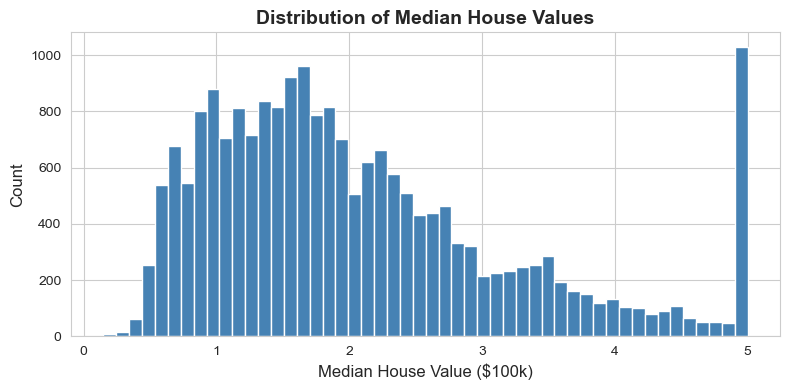

📈 Plot saved: target_distribution.png


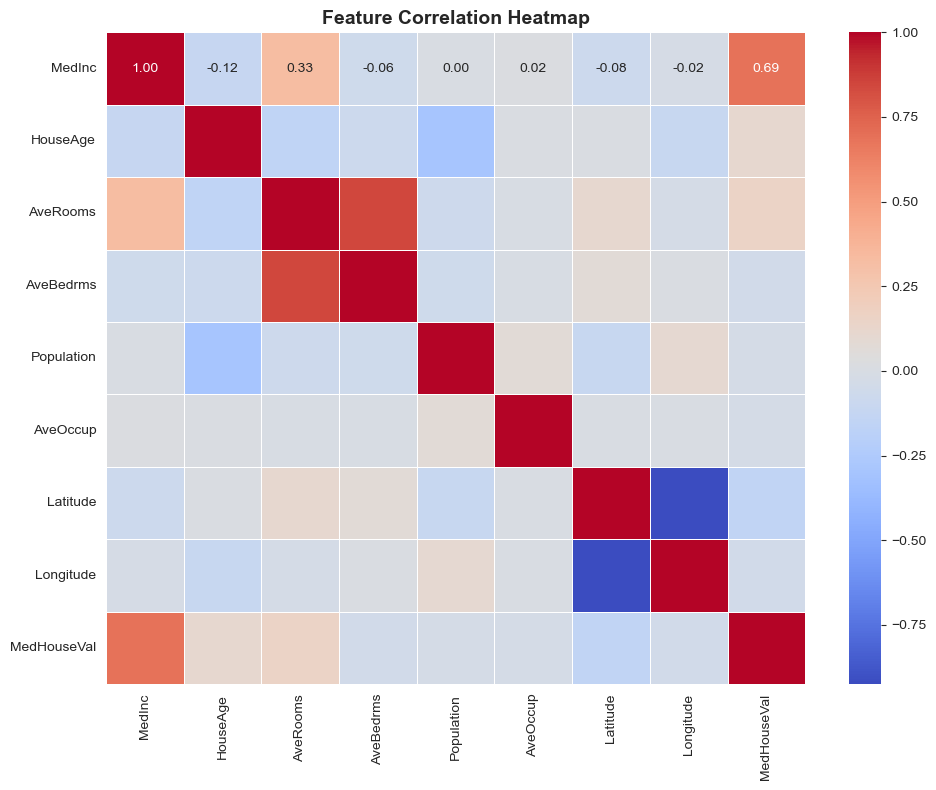

📈 Plot saved: correlation_heatmap.png

 Feature correlations with MedHouseVal (target):
MedInc        0.6881
AveRooms      0.1519
HouseAge      0.1056
AveOccup     -0.0237
Population   -0.0246
Longitude    -0.0460
AveBedrms    -0.0467
Latitude     -0.1442
Name: MedHouseVal, dtype: float64


In [4]:
#EDA
print("\n Statistical Summary:")
print(df.describe().round(2))

print("\n Missing Values:")
print(df.isnull().sum())
print(f"Total missing: {df.isnull().sum().sum()}")

# --- Plot 1: Target Distribution ---
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Median House Value ($100k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Median House Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=130)
plt.show()
print("📈 Plot saved: target_distribution.png")

# --- Plot 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=130)
plt.show()
print("📈 Plot saved: correlation_heatmap.png")

# Correlation with target
print("\n Feature correlations with MedHouseVal (target):")
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(corr)



In [6]:
# FEATURE SELECTION 
X = df.drop(columns='MedHouseVal')  
y = df['MedHouseVal']                

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n Training samples : {len(X_train):,}")
print(f"   Testing  samples : {len(X_test):,}")
print(f"   Features         : {X.shape[1]}")



 Training samples : 16,512
   Testing  samples : 4,128
   Features         : 8



 Model trained successfully!
   Intercept: -37.0233

   Feature Coefficients:
   Feature  Coefficient
 AveBedrms       0.7831
    MedInc       0.4487
  HouseAge       0.0097
Population      -0.0000
  AveOccup      -0.0035
  AveRooms      -0.1233
  Latitude      -0.4198
 Longitude      -0.4337


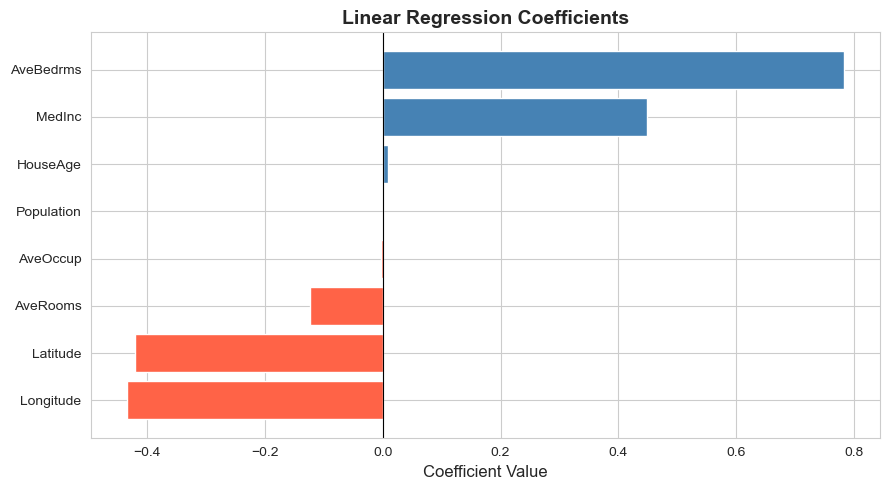

 Plot saved: coefficients.png


In [7]:
# MODEL TRAINING
model = LinearRegression()
model.fit(X_train, y_train)

print("\n Model trained successfully!")
print(f"   Intercept: {model.intercept_:.4f}")
print("\n   Feature Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_sorted['Coefficient']]
plt.figure(figsize=(9, 5))
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=130)
plt.show()
print(" Plot saved: coefficients.png")


In [10]:
# EVALUATION 
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n" + "=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")
print("=" * 45)
print(f"\n  Average prediction error: ${mae * 100_000:,.0f}")


        MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error)  : 0.5332
  RMSE (Root Mean Sq. Error)  : 0.7456
  R²   (Coefficient of Det.)  : 0.5758

  Average prediction error: $53,320


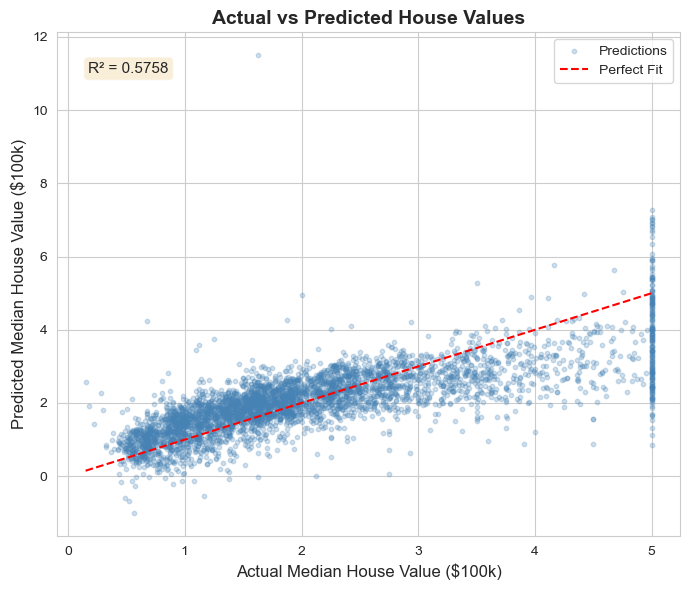

 Plot saved: actual_vs_predicted.png


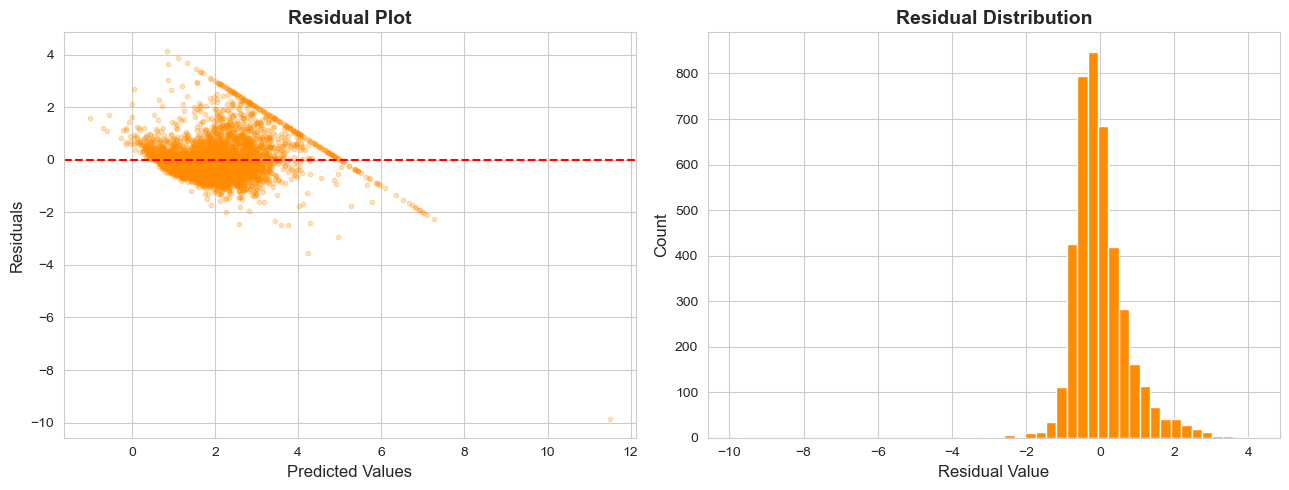

Plot saved: residuals.png

   Residual Mean : 0.003479  (should be ~0)
   Residual Std  : 0.7457

 Model saved as: california_housing_lr_model.pkl


In [11]:
# ── 7. PLOTS ──────────────────────────────────────────────────

# --- Plot 4: Actual vs Predicted ---
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=10, color='steelblue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1.5, label='Perfect Fit')
plt.xlabel('Actual Median House Value ($100k)', fontsize=12)
plt.ylabel('Predicted Median House Value ($100k)', fontsize=12)
plt.title('Actual vs Predicted House Values', fontsize=14, fontweight='bold')
plt.legend()
plt.text(0.05, 0.92, f'R² = {r2:.4f}', transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=130)
plt.show()
print(" Plot saved: actual_vs_predicted.png")

# --- Plot 5: Residuals ---
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.25, s=10, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14, fontweight='bold')

axes[1].hist(residuals, bins=50, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Residual Value', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('residuals.png', dpi=130)
plt.show()
print("Plot saved: residuals.png")

print(f"\n   Residual Mean : {residuals.mean():.6f}  (should be ~0)")
print(f"   Residual Std  : {residuals.std():.4f}")


# SAVE MODEL 
with open('california_housing_lr_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("\n Model saved as: california_housing_lr_model.pkl")



In [13]:
#  SAMPLE PREDICTION 
with open('california_housing_lr_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = pd.DataFrame([{
    'MedInc'    : 5.0,    # Median income $50,000
    'HouseAge'  : 25,     # 25 years old
    'AveRooms'  : 5.5,    # 5.5 rooms avg
    'AveBedrms' : 1.1,    # 1.1 bedrooms avg
    'Population': 1200,   # 1200 people
    'AveOccup'  : 3.0,    # 3 people per household
    'Latitude'  : 34.0,   # Southern California
    'Longitude' : -118.0  # Los Angeles area
}])

prediction = loaded_model.predict(sample)[0]
print("\n Sample Prediction:")
print(sample.to_string(index=False))
print(f"\n   Predicted Median House Value: ${prediction * 100_000:,.0f}")



 Sample Prediction:
 MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
 5.0000        25    5.5000     1.1000        1200    3.0000   34.0000  -118.0000

   Predicted Median House Value: $253,798
